In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

In [2]:
california = fetch_california_housing()
type(california)

sklearn.utils._bunch.Bunch

In [3]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
y = data["Price"]
X = data.drop("Price", axis = 1)
y.shape


(20640,)

In [7]:
class Model(object):
    def __init__(self, weights=None):
        self.weights = np.asarray(self.weights) if weights is not None else None

    def _validate_X(self, X):
        if isinstance(X, pd.DataFrame):
            return X.values
        elif isinstance(X, pd.Series):
            return X.values.reshape(-1, 1)
        else:
            arr = np.asarray(X)
            if arr.ndim == 1:
                return arr.reshape(-1, 1)
            return arr

    def _validate_Y(self, Y):
        if isinstance(Y, (pd.DataFrame, pd.Series)):
            return Y.values.flatten()
        return np.asarray(Y).flatten()

    def predict(self, X):
        X = self._validate_X(X)
        if self.weights is None:
            raise ValueError("нет весов")

        X_bias = np.c_[np.ones(X.shape[0]), X]
        return np.dot(X_bias, self.weights)

    def error(self, X, Y):
        X = self._validate_X(X)
        Y = self._validate_Y(Y)
        predictions = self.predict(X)
        return np.sum((predictions -Y)**2) / (2*len(X))

    def fit(self, X, Y, accuracy=0.0001, max_steps=5000, alpha=1.0):
        X = self._validate_X(X)
        Y = self._validate_Y(Y)
        n_samples, n_features = X.shape

        if self.weights is None or len(self.weights) != (n_features + 1):
            self.weights = np.zeros(n_features + 1)

        X_bias = np.c_[np.ones(n_samples), X]
        steps, errors = [], []
        step = 0
        prev_err = self.error(X, Y)

        while step < max_steps:
            predictions = np.dot(X_bias, self.weights)
            diff = predictions - Y

            dJ = np.dot(X_bias.T, diff) / n_samples
            old_weights = self.weights.copy()
            self.weights -= alpha * dJ
            new_err = self.error(X, Y)

            if new_err > prev_err:
                self.weights = old_weights
                alpha /= 2

                if alpha < 1e-12:
                    break
                continue
            else:
                step += 1
                steps.append(step)
                errors.append(new_err)
                if abs(prev_err-new_err) < accuracy:
                    break
                prev_error=new_err
        return steps, errors

    def plot(self, X, Y):
        X = self._validate_X(X)
        Y = self._validate_Y(Y)
        Y_pred = self.predict(X)

        plt.figure(figsize=(8, 6))
        plt.scatter(Y, Y_pred, alpha=0.7, color='blue', label='Данные')

        min_val = min(Y.min(), Y_pred.min())
        max_val = max(Y.max(), Y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')

        plt.xlabel('Реальные значения (Y)')
        plt.ylabel('Предсказанные значения (Y_pred)')
        plt.title('Диаграмма рассеяния: Реальность vs Предсказание')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

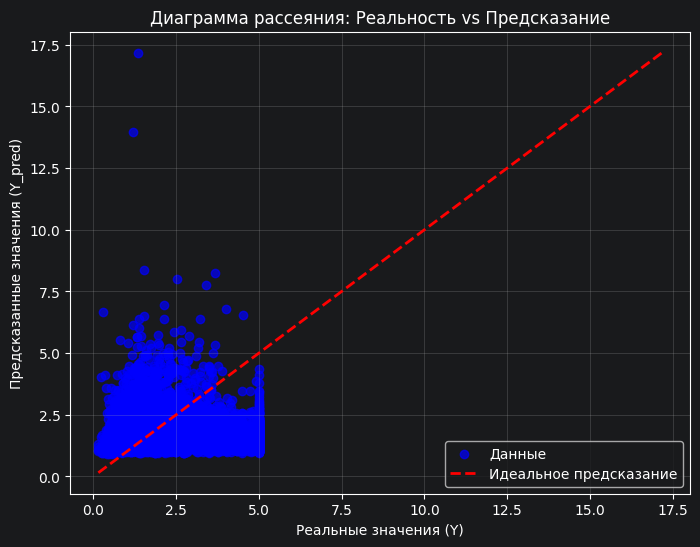

In [8]:
M = Model()
steps, errors = M.fit(X, y, alpha=1e-8, max_steps=(10**4))
M.plot(X, y)

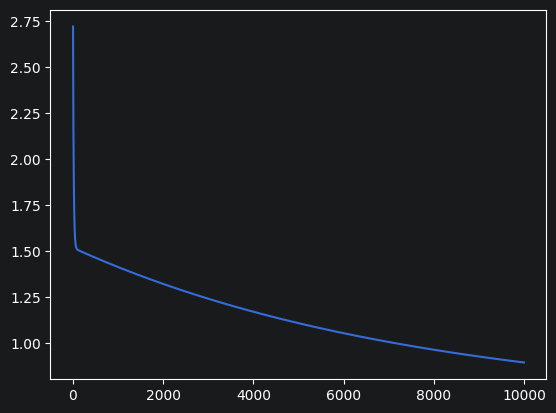

In [9]:
plt.figure()
plt.plot(steps, errors)
plt.show()

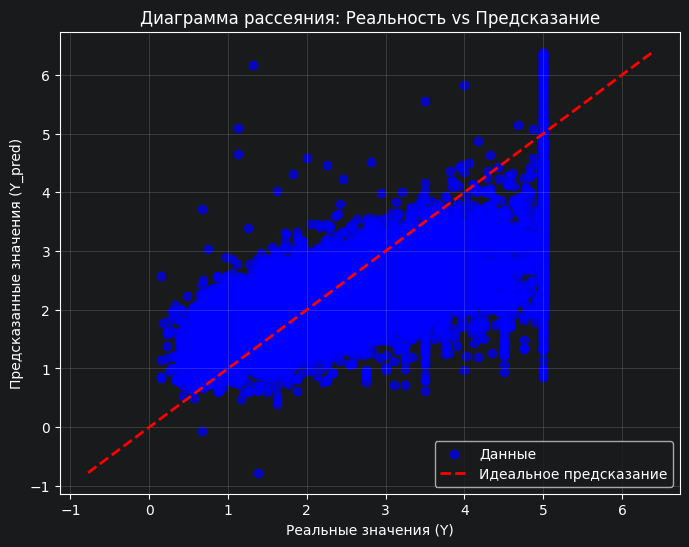

In [10]:
M = Model()
steps, errors = M.fit(X, y, accuracy=1e-8, max_steps=(10**6))
M.plot(X, y)

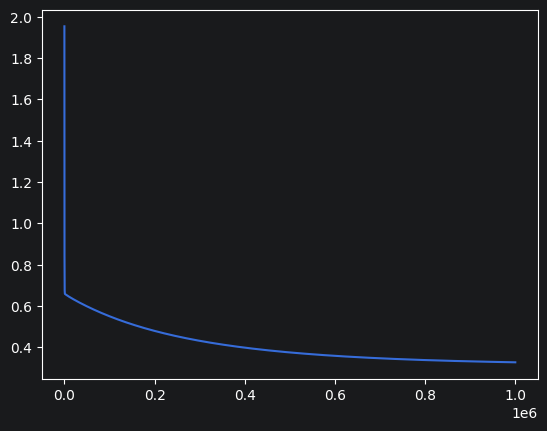

In [84]:
plt.figure()
plt.plot(steps, errors)
plt.show()

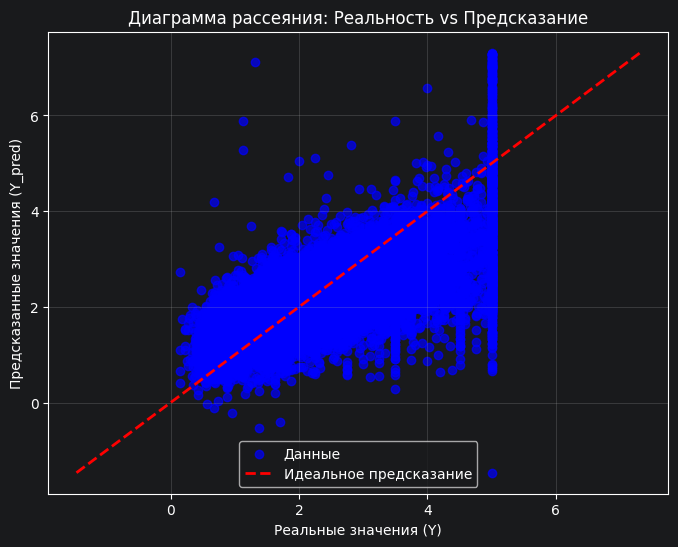

In [11]:
M = Model()
steps, errors = M.fit(X, y, accuracy=1e-8, max_steps=(10**7))
M.plot(X, y)

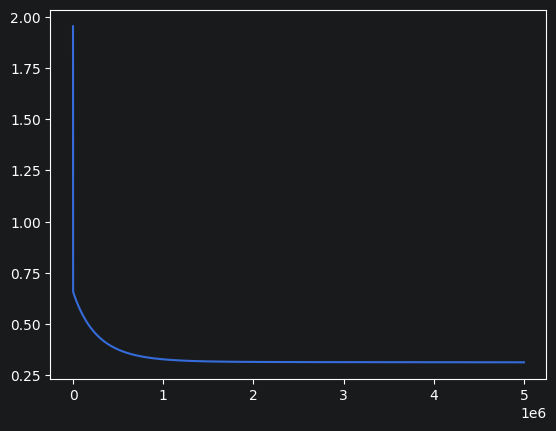

In [86]:
plt.figure()
plt.plot(steps, errors)
plt.show()